##### This notebook creates STDNN-SE (pytorch) for classification prediction on Tox21

Using split data already saved.

Notebook shows results for seed = 124, but we also ran on seed 122, 123. 

Before use define desired pathways to save models,:
- path variable, in "Create checkpoint" section for models
- writer variable, in "Train the neural network model" section for tensorboard summary

In [1]:
# general and data handling
import numpy as np
import pandas as pd
import os
from collections import Counter

# Required RDKit modules
import rdkit as rd
from rdkit import DataStructs
from rdkit.Chem import AllChem

# modeling
import sklearn as sk
from sklearn.model_selection import train_test_split

# Graphing
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import time
import random
import joblib

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, brier_score_loss

In [4]:
import torch
device=torch.device("cuda:0" if torch.cuda.is_available() else "cpu")  

In [5]:
# Load the TensorBoard notebook extension
%load_ext tensorboard

In [6]:
# Ensure runs on GPU
import tensorflow as tf
import datetime, os

2026-02-15 18:50:54.080031: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-15 18:50:54.138408: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-15 18:50:54.437296: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-15 18:50:55.674668: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


##### Settings

In [7]:
# set seed value
seed_value = 124 #122 123 124, as used in MoleculeNet
torch.manual_seed(seed_value)
torch.cuda.manual_seed(seed_value)
np.random.seed(seed_value)
random.seed(seed_value)
torch.backends.cudnn.enabled=False
torch.backends.cudnn.deterministic=True

In [8]:
# number of bits for morgan fingerprints
morgan_bits = 4096

In [9]:
# number of radius for morgan fingerprints
morgan_radius = 2

In [10]:
train_epoch = 50 

In [11]:
batch = 512 

##### Load raw data

In [12]:
tox21_file  = '../../../../data/datasets/tox21/raw_data/tox21.csv'
tox21_tasks = ['NR-AR', 'NR-Aromatase', 'NR-PPAR-gamma', 'SR-HSE', 
               'NR-AR-LBD', 'NR-ER', 'SR-ARE', 'SR-MMP',
               'NR-AhR', 'NR-ER-LBD', 'SR-ATAD5', 'SR-p53']

tox21_data = pd.read_csv(tox21_file)
print('Reading {}... {} data loaded.'.format(tox21_file, len(tox21_data)))
tox21_data.head()

Reading ../../../../data/datasets/tox21/raw_data/tox21.csv... 8014 data loaded.


,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,mol_id,smiles
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3027,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C
4,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,TOX3028,CC(O)(P(=O)(O)O)P(=O)(O)O


#####  Setting all tasks 

In [13]:
data = [tox21_data] 

In [14]:
all_tasks = tox21_tasks 

##### Load split data

In [15]:
# load saved tox21 train/test/valid data 
# Load and split clintox data using seed_124
# Since the pickled .pth files have pandas compatibility issues, 
# we'll recreate the splits from raw CSV

tox21_raw_file = "../../../../data/datasets/tox21/raw_data/tox21.csv"
tox21_data_path = "../../../../data/datasets/tox21/split_data/seed_124/"

# Load raw data
tox21_raw = pd.read_csv(tox21_raw_file)
print(f"Raw data loaded: {len(tox21_raw)} samples")
print(tox21_raw.head())

# Create splits using seed 124 (same as MoleculeNet)
# MoleculeNet uses 80% train, 10% valid, 10% test split
from sklearn.model_selection import train_test_split

seed = 124

# First split: 80% train, 20% temp (for valid+test)
train_data, temp_data = train_test_split(
    tox21_raw, 
    test_size=0.2, 
    random_state=seed
)

# Second split: split the 20% into 50-50 for valid and test
valid_data, test_data = train_test_split(
    temp_data, 
    test_size=0.5, 
    random_state=seed
)

print(f"\nData split sizes:")
print(f"  Train: {len(train_data)}")
print(f"  Valid: {len(valid_data)}")
print(f"  Test:  {len(test_data)}")

# Convert to DataFrames (they should already be)
train_data = train_data.reset_index(drop=True)
valid_data = valid_data.reset_index(drop=True)
test_data = test_data.reset_index(drop=True)

data = [train_data, test_data, valid_data]
print("\n✓ Data splits created successfully!")

Raw data loaded: 8014 samples
   NR-AR  NR-AR-LBD  NR-AhR  NR-Aromatase  NR-ER  NR-ER-LBD  NR-PPAR-gamma  \
0    0.0        0.0     1.0           NaN    NaN        0.0            0.0   
1    0.0        0.0     0.0           0.0    0.0        0.0            0.0   
2    NaN        NaN     NaN           NaN    NaN        NaN            NaN   
3    0.0        0.0     0.0           0.0    0.0        0.0            0.0   
4    0.0        0.0     NaN           0.0    0.0        0.0            0.0   

   SR-ARE  SR-ATAD5  SR-HSE  SR-MMP  SR-p53   mol_id  \
0     1.0       0.0     0.0     0.0     0.0  TOX3021   
1     NaN       0.0     NaN     0.0     0.0  TOX3020   
2     0.0       NaN     0.0     NaN     NaN  TOX3024   
3     NaN       0.0     NaN     0.0     0.0  TOX3027   
4     0.0       0.0     0.0     NaN     0.0  TOX3028   

                                              smiles  
0                       CCOc1ccc2nc(S(N)(=O)=O)sc2c1  
1                          CCN1C(=O)NC(c2ccccc2)C1=O  

In [16]:
print("Total number of examples, train: " + str(data[0].shape[0]))
print("Total number of examples, test: " + str(data[1].shape[0]))
print("Total number of examples, valid: " + str(data[2].shape[0]))
print("Total number of examples, train+test+valid: " + str(data[0].shape[0] + data[1].shape[0] + data[2].shape[0]))

Total number of examples, train: 6411
Total number of examples, test: 802
Total number of examples, valid: 801
Total number of examples, train+test+valid: 8014


##### SMILES embedding featurization 

In [17]:
# Load existing SE featurization - dictionary of SMILES embedding given a SMILES
smiles_embed = torch.load("../../../../data/smiles_embedding/toxicity_smiles.pt")

/tmp/ipykernel_39878/1126325801.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  smiles_embed = torch.load("../../../../data/smiles_embedding/toxicity_smiles.pt")


In [18]:
# Obtain SMILES Embedding for given SMILES 
for i in range(len(data)):
    data[i]['smiles_embed'] = data[i]['smiles'].apply(lambda x: smiles_embed.get(x))

In [19]:
# Check if any NA 
sum = 0 
for i in range(len(data)):
    na = data[i]['smiles_embed'].isna().sum()
    sum = sum + na
print(sum)

0


##### Create train, test, valid sets

In [20]:
# replace NA with -1 -- used to deal with missing labels, 
#                       along with Binary Cross-Entropy loss
data[0] = data[0].fillna(-1)
data[1] = data[1].fillna(-1)
data[2] = data[2].fillna(-1)

In [21]:
train_data = data[0]
test_data  = data[1]
valid_data = data[2]

In [22]:
## Arrays for train / test / valid sets used for DNN 
# convert column with embedding to array
x_train = []
for tensor in train_data['smiles_embed']:
    x_train.append(tensor)

x_train = torch.stack(x_train)
x_train = x_train.numpy()

y_train = train_data[all_tasks].values

In [23]:
# convert column with embedding to array
x_test = []

for tensor in test_data['smiles_embed']:
    x_test.append(tensor)
x_test = torch.stack(x_test)
x_test = x_test.numpy()

y_test = test_data[all_tasks].values

In [24]:
# convert column with embedding to array
x_valid = []
for tensor in valid_data['smiles_embed']:
    x_valid.append(tensor)
x_valid = torch.stack(x_valid)
x_valid = x_valid.numpy()

    
y_valid = valid_data[all_tasks].values

In [25]:
# count the number of data points per class
N_train = np.sum(y_train >= 0, 0)
N_test  = np.sum(y_test >= 0, 0)
N_valid  = np.sum(y_valid >= 0, 0)

##### Deep Neural Network (pytorch)

In [26]:
import torch
from torch.utils.data import Dataset, DataLoader

In [27]:
# convert data for pytorch
x_train_torch = x_train.astype(np.float32)
y_train_torch = y_train.astype(np.float32)

x_test_torch = x_test.astype(np.float32)
y_test_torch = y_test.astype(np.float32)

x_valid_torch = x_valid.astype(np.float32)
y_valid_torch = y_valid.astype(np.float32)

In [28]:
input_shape = x_train_torch.shape[1]
input_shape

128

In [29]:
# Class for STDNN data
class STDNNData(Dataset):

    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

In [30]:
training_set = STDNNData(x_train_torch, y_train_torch)
training_generator = DataLoader(training_set, batch_size=batch, shuffle=True)

testing_set = STDNNData(x_test_torch, y_test_torch)
testing_generator = DataLoader(testing_set, batch_size=len(testing_set), shuffle=False)

valid_set = STDNNData(x_valid_torch, y_valid_torch)
valid_generator = DataLoader(valid_set, batch_size=len(valid_set), shuffle=False)

In [31]:
# DNN Model class
# Each 12 tasks are treated as separate tasks with 2 separate layers
class DNN(torch.nn.Module):
    def __init__(self, input_shape, all_tasks):
        super(DNN, self).__init__()

        self.hidden_1 = torch.nn.ModuleList([torch.nn.Linear(input_shape, 1024) for task in all_tasks])
        self.batchnorm_1 = torch.nn.ModuleList([torch.nn.BatchNorm1d(1024) for task in all_tasks])
        
        self.hidden_2 = torch.nn.ModuleList([torch.nn.Linear(1024, 512) for task in all_tasks])
        self.batchnorm_2 = torch.nn.ModuleList([torch.nn.BatchNorm1d(512) for task in all_tasks])
        
        self.output   = torch.nn.ModuleList([torch.nn.Linear(512, 1) for task in all_tasks])
        
        # function for leaky ReLU
        self.leakyReLU = torch.nn.LeakyReLU(0.05)

    def forward(self, x):        
        x_task = [None for i in range(len(self.output))]  # initialize
        for task in range(len(self.output)):
            x_task[task] = self.hidden_1[task](x)
            x_task[task] = self.batchnorm_1[task](x_task[task])
            x_task[task] = self.leakyReLU(x_task[task])
            
            x_task[task] = self.hidden_2[task](x_task[task])
            x_task[task] = self.batchnorm_2[task](x_task[task])
            x_task[task] = self.leakyReLU(x_task[task])
            
            x_task[task] = self.output[task](x_task[task])
            x_task[task] = torch.sigmoid(x_task[task])
        
        y_pred = x_task
        
        return y_pred
    
model = DNN(input_shape, all_tasks).to(device)

###### Create checkpoint - saving and loading best model 

In [32]:
## Method from : https://gist.github.com/vsay01/45dfced69687077be53dbdd4987b6b17

import shutil
def save_ckp(state, is_best, checkpoint_path, best_model_path):
    """
    state: checkpoint we want to save
    is_best: is this the best checkpoint; min validation loss
    checkpoint_path: path to save checkpoint
    best_model_path: path to save best model
    """
    f_path = checkpoint_path
    # save checkpoint data to the path given, checkpoint_path
    torch.save(state, f_path)
    # if it is a best model, min validation loss
    if is_best:
        best_fpath = best_model_path
        # copy that checkpoint file to best path given, best_model_path
        shutil.copyfile(f_path, best_fpath)

In [33]:
def load_ckp(checkpoint_fpath, input_model, optimizer):
    """
    checkpoint_path: path to save checkpoint
    model: model that we want to load checkpoint parameters into       
    optimizer: optimizer we defined in previous training
    """
    # load check point
    checkpoint = torch.load(checkpoint_fpath)
    # initialize state_dict from checkpoint to model
    input_model.load_state_dict(checkpoint['state_dict'])
    # initialize optimizer from checkpoint to optimizer
    optimizer.load_state_dict(checkpoint['optimizer'])
    # initialize valid_loss_min from checkpoint to valid_loss_min
    train_loss_min = checkpoint['train_loss_min']
    # return model, optimizer, epoch value, min validation loss 
    return model, optimizer, checkpoint['epoch'], train_loss_min.item()

In [34]:
# Create directory to save models
import os

# Define a path where you want to save the trained models
output_dir = './trained_models/STDNN_SE_tox21_seed124'

# Create the directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)
print(f"✓ Model output directory created: {output_dir}")

✓ Model output directory created: ./trained_models/STDNN_SE_tox21_seed124


In [35]:
path = output_dir

In [36]:
###### Pathways to save models 
checkpoint_path = path + '/current_checkpoint.pt'

#Path to saved model when train_epoch_loss <= train_loss_min
bestmodel_path = path + '/best_model.pt'  

#Path to saved model at minimum valid loss
bestmodel_byvalid = path + '/best_model_by_valid.pt' 

#Path to saved  when train_epoch_loss >= val_epoch_loss
bestmodel_byvalid_crossed = path + '/best_model_by_valid-crossed.pt'   

##### Train the neural network model

In [37]:
# Define the loss
pos_weight = torch.tensor([3.0]).to(device)  # Increase this value to penalize false negatives more
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Optimizers require the parameters to optimize and a learning rate
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

In [38]:
# Try different pos_weight values and collect results for all endpoints
import os
pos_weights = [1.0, 2.0, 3.0, 5.0, 10.0, 15.0, 20.0, 30.0, 40.0, 50.0]
personalized_weights = [20, 20, 20, 30, 15, 50, 40, 15, 40, 50, 15, 30]
all_results = []

for pw in pos_weights:
    print(f"\n==== Training with pos_weight={pw} ====")
    pos_weight = torch.tensor([pw]).to(device)
    criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    
    # Re-initialize model and optimizer for each run
    model = DNN(input_shape, all_tasks).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    
    # Training loop (shortened for demonstration; use your full loop in practice)
    for e in range(5):  # Use fewer epochs for quick comparison; increase as needed
        model.train()
        for x_batch, y_batch in training_generator:
            if torch.cuda.is_available():
                x_batch, y_batch = x_batch.cuda(), y_batch.cuda()
            y_pred = model(x_batch)
            loss = 0
            for i in range(len(all_tasks)):
                y_batch_task = y_batch[:,i]
                y_pred_task  = y_pred[i][:,0]
                indice_valid = y_batch_task >= 0
                loss_task = criterion(y_pred_task[indice_valid], y_batch_task[indice_valid]) / N_train[i]
                loss += loss_task
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    # Evaluate on test set
    model.eval()
    with torch.no_grad():
        for x_test_torch, y_test_torch in testing_generator:
            y_test_pred = model(x_test_torch)
            for i in range(len(all_tasks)):
                valid_datapoints = y_test[:,i] >= 0
                y_test_task = y_test[valid_datapoints,i]
                y_test_pred_task = y_test_pred[i].detach().cpu().numpy()[valid_datapoints,0]
                acc = accuracy_score(y_test_task, np.round(y_test_pred_task))
                bacc = sk.metrics.balanced_accuracy_score(y_test_task, np.round(y_test_pred_task))
                f1 = f1_score(y_test_task, np.round(y_test_pred_task), pos_label=1)
                cfm = sk.metrics.confusion_matrix(y_test_task, np.round(y_test_pred_task))
                cfm = cfm.astype('float') / cfm.sum(axis=1)[:, np.newaxis]
                tn, fp, fn, tp = cfm.ravel()
                pr = tp / (tp + fp) if (tp + fp) > 0 else 0
                rc = tp / (tp + fn) if (tp + fn) > 0 else 0
                auc = roc_auc_score(y_test_task, y_test_pred_task)
                all_results.append({
                    'ENDPOINT': all_tasks[i],
                    'pos_weight': pw,
                    'AUC': auc,
                    'ACC': acc,
                    'BACC': bacc,
                    'TN': round(tn, 4),
                    'TP': round(tp, 4),
                    'FP': round(fp, 4),
                    'FN': round(fn, 4),
                    'PR': round(pr, 4),
                    'RC': round(rc, 4),
                    'F1': round(f1, 4)
                })
    # Save model only if pos_weight matches personalized_weights for any endpoint
    for idx, pw_target in enumerate(personalized_weights):
        if pw == pw_target:
            model_save_path = f'./trained_models/STDNN_SE_tox21_seed124/model_{all_tasks[idx]}_pw{pw}.pt'
            torch.save(model.state_dict(), model_save_path)

# Save all results to CSV, appending if file exists
import pandas as pd
results_df = pd.DataFrame(all_results)
output_csv_path = '../../../../results/mt_vs_st.csv'
if os.path.exists(output_csv_path):
    existing = pd.read_csv(output_csv_path)
    results_df = pd.concat([existing, results_df], ignore_index=True)
results_df.to_csv(output_csv_path, index=False)
print(f"✓ All pos_weight results appended to {output_csv_path}")
results_df.head()


==== Training with pos_weight=1.0 ====

==== Training with pos_weight=2.0 ====

==== Training with pos_weight=3.0 ====

==== Training with pos_weight=5.0 ====

==== Training with pos_weight=10.0 ====

==== Training with pos_weight=15.0 ====

==== Training with pos_weight=20.0 ====

==== Training with pos_weight=30.0 ====

==== Training with pos_weight=40.0 ====

==== Training with pos_weight=50.0 ====
✓ All pos_weight results appended to ../../../../results/mt_vs_st.csv


,ENDPOINT,pos_weight,AUC,ACC,BACC,TN,TP,FP,FN,PR,RC,F1
0,NR-AR,1.0,0.858941,0.974150,0.720588,1.0000,0.4412,0.0000,0.5588,1.0000,0.4412,0.6122
1,NR-Aromatase,1.0,0.825238,0.938356,0.526113,0.9982,0.0541,0.0018,0.9459,0.9673,0.0541,0.1000
2,NR-PPAR-gamma,1.0,0.773203,0.975347,0.500000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000
3,SR-HSE,1.0,0.833143,0.938838,0.500000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000
4,NR-AR-LBD,1.0,0.864888,0.976574,0.736100,0.9939,0.4783,0.0061,0.5217,0.9875,0.4783,0.5789


### Experiment: Try different pos_weight values for penalizing false negatives
We will train and evaluate the model for several pos_weight values and save all results to mt_vs_st.csv for comparison.

In [39]:
from torch.utils.tensorboard import SummaryWriter

# Define the desired pathway
writer = SummaryWriter('define-pathway/')

In [40]:
%%time
##################### With Tensorboard ######################
loss_history=[]  
correct_history=[]  
val_loss_history=[]  
val_correct_history=[] 
train_loss_min = np.Inf
val_loss_min = np.Inf


# Training
for e in range(train_epoch):
    
    model.train()
    # keep track of the loss over an epoch
    running_train_loss = 0
    running_valid_loss = 0
    running_train_correct = 0
    running_val_correct = 0
    y_train_true = []
    y_train_pred = []
    y_valid_true = []
    y_valid_pred = []
    batch_num = 0
    for x_batch, y_batch in training_generator:
        batch_num += 1
        if torch.cuda.is_available():
            x_batch, y_batch = x_batch.cuda(), y_batch.cuda() 
        
        # Forward pass: Compute predicted y by passing x to the model
        y_pred = model(x_batch)  # for all tasks
        
        # Compute loss over all tasks
        loss = 0
        correct = 0
        y_train_true_task = []
        y_train_pred_task = []
        for i in range(len(all_tasks)):
            y_batch_task = y_batch[:,i]
            y_pred_task  = y_pred[i][:,0] #check if predictions na
            
            # compute loss for labels that are not NA
            indice_valid = y_batch_task >= 0
            loss_task = criterion(y_pred_task[indice_valid], y_batch_task[indice_valid]) / N_train[i]
            
            loss += loss_task

            pred_train = np.round(y_pred_task[indice_valid].detach().cpu().numpy())
            target_train = y_batch_task[indice_valid].float()
            y_train_true.extend(target_train.tolist()) 
            y_train_pred.extend(pred_train.reshape(-1).tolist())

        # Zero gradients, perform a backward pass, and update the weights.
        writer.add_scalar("Accuracy/train", loss, batch_num)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
        # sum up the losses from each batch
        running_train_loss += loss.item()
        writer.add_scalar("Loss/train", running_train_loss, e)
        
    else:
        with torch.no_grad():    
        ## evaluation part 
            model.eval()
            for val_x_batch, val_y_batch in valid_generator:
                
                if torch.cuda.is_available():
                    val_x_batch, val_y_batch = val_x_batch.cuda(), val_y_batch.cuda() 
                
                val_output = model(val_x_batch)

                ## 2. loss calculation over all tasks 
                val_loss = 0
                val_correct = 0
                y_valid_true_task = []
                y_valid_pred_task = []
                for i in range(len(all_tasks)):
                    val_y_batch_task = val_y_batch[:,i]
                    val_output_task  = val_output[i][:,0]

                    # compute loss for labels that are not NA
                    indice_valid = val_y_batch_task >= 0
                    val_loss_task = criterion(val_output_task[indice_valid], val_y_batch_task[indice_valid]) / N_valid[i]

                    val_loss += val_loss_task
                    
                    pred_valid = np.round(val_output_task[indice_valid].detach().cpu().numpy())
                    target_valid = val_y_batch_task[indice_valid].float()
                    y_valid_true.extend(target_valid.tolist()) 
                    y_valid_pred.extend(pred_valid.reshape(-1).tolist())
                

                running_valid_loss+=val_loss.item()
                writer.add_scalar("Loss/valid", running_valid_loss, e)
        
        #epoch loss
        train_epoch_loss=np.mean(running_train_loss)
        val_epoch_loss=np.mean(running_valid_loss)  
       
        #epoch accuracy      
        train_epoch_acc = accuracy_score(y_train_true,y_train_pred)
        val_epoch_acc = accuracy_score(y_valid_true,y_valid_pred)
        
        #history
        loss_history.append(train_epoch_loss)  
        correct_history.append(train_epoch_acc)
        val_loss_history.append(val_epoch_loss)  
        val_correct_history.append(val_epoch_acc)  
        
        print("Epoch:", e, "Training Loss:", train_epoch_loss, "Valid Loss:", val_epoch_loss)
        print("Training Acc:", train_epoch_acc, "Valid Acc:", val_epoch_acc)
        
        # create checkpoint variable and add important data
        checkpoint = {
            'epoch': e + 1,
            'train_loss_min': train_epoch_loss,
            'val_loss_min': val_epoch_loss, 
            'state_dict': model.state_dict(),
            'optimizer': optimizer.state_dict(),
        }
        
        # save checkpoint
        save_ckp(checkpoint, False, checkpoint_path, bestmodel_path)
        
        ## TODO: save the model if validation loss has decreased
        if train_epoch_loss <= train_loss_min:
            print('Training loss decreased ({:.6f} --> {:.6f}).  Saving model ...'.format(train_loss_min,train_epoch_loss))
            # save checkpoint as best model
            save_ckp(checkpoint, True, checkpoint_path, bestmodel_path)
            train_loss_min = train_epoch_loss
            
        if train_epoch_loss >= val_epoch_loss:
            print('Training loss greater than validation loss ({:.6f} --> {:.6f}).  Saving model ...'.format(train_epoch_loss,val_epoch_loss))
            # save checkpoint as best model
            save_ckp(checkpoint, True, checkpoint_path, bestmodel_byvalid_crossed)
            train_loss_min = train_epoch_loss
            
        if val_epoch_loss <= val_loss_min:
            print('Validation loss decreased ({:.6f} --> {:.6f}). Saving model ...'.format(val_loss_min,val_epoch_loss))
            # save checkpoint as best model
            save_ckp(checkpoint, True, checkpoint_path, bestmodel_byvalid)
            val_loss_min = val_epoch_loss

Epoch: 0 Training Loss: 0.06149393739178777 Valid Loss: 0.04034414887428284
Training Acc: 0.7669669386407584 Valid Acc: 0.7541671811334733
Training loss decreased (inf --> 0.061494).  Saving model ...
Training loss greater than validation loss (0.061494 --> 0.040344).  Saving model ...
Validation loss decreased (inf --> 0.040344). Saving model ...
Epoch: 1 Training Loss: 0.06108733918517828 Valid Loss: 0.04043138027191162
Training Acc: 0.7888820764357245 Valid Acc: 0.7692307692307693
Training loss decreased (0.061494 --> 0.061087).  Saving model ...
Training loss greater than validation loss (0.061087 --> 0.040431).  Saving model ...
Epoch: 2 Training Loss: 0.06066718278452754 Valid Loss: 0.04071468114852905
Training Acc: 0.807102768476159 Valid Acc: 0.7776268675145079
Training loss decreased (0.061087 --> 0.060667).  Saving model ...
Training loss greater than validation loss (0.060667 --> 0.040715).  Saving model ...
Epoch: 3 Training Loss: 0.060060443822294474 Valid Loss: 0.04109811

In [41]:
# Loads model at lowest validation loss 
loaded_model, optimizer, start_epoch, train_loss_min = load_ckp(bestmodel_byvalid, model, optimizer)

/tmp/ipykernel_39878/1156039392.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_fpath)


##### Evaluate on test set

In [42]:
# print test loss
for x_test_torch, y_test_torch in testing_generator:
    y_test_pred = model.eval().to(device).cpu()(x_test_torch)
    
    # Compute loss over all tasks
    loss = 0
    for i in range(len(all_tasks)):
        y_test_task = y_test_torch[:,i]
        y_pred_task  = y_test_pred[i][:,0]

        # compute loss for labels that are not NA
        indice_valid = y_test_task >= 0
        loss_task = criterion(y_pred_task[indice_valid], y_test_task[indice_valid]) / N_test[i]

        loss += loss_task
    
print(loss.item())

0.04217109456658363


Accuracy for MTDNN on Morgan Fingerprint: 0.8027210884353742
F1 for MTDNN on Morgan Fingerprint: 0.25641025641025644
 True Positive: 0.7352941176470589
 True Negative: 0.8059914407988588
False Positive: 0.19400855920114124
False Negative: 0.2647058823529412
Test ROC AUC (NR-AR): 0.8402702022321055


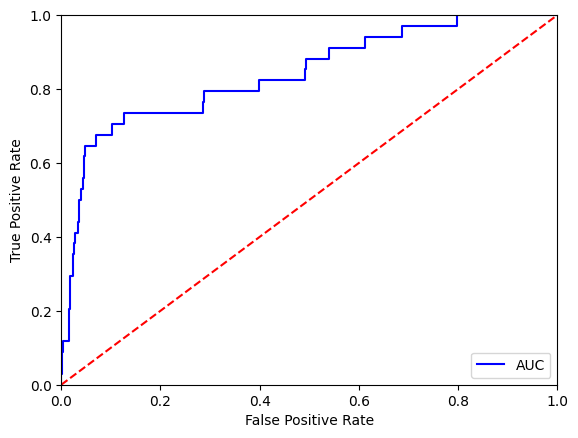

Accuracy for MTDNN on Morgan Fingerprint: 0.791095890410959
F1 for MTDNN on Morgan Fingerprint: 0.3146067415730337
 True Positive: 0.7567567567567568
 True Negative: 0.793418647166362
False Positive: 0.20658135283363802
False Negative: 0.24324324324324326
Test ROC AUC (NR-Aromatase): 0.8092297050249518


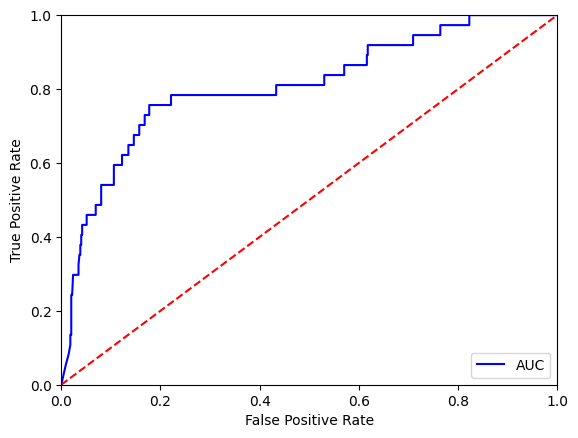

Accuracy for MTDNN on Morgan Fingerprint: 0.9214175654853621
F1 for MTDNN on Morgan Fingerprint: 0.30136986301369867
 True Positive: 0.6875
 True Negative: 0.9273301737756714
False Positive: 0.07266982622432859
False Negative: 0.3125
Test ROC AUC (NR-PPAR-gamma): 0.8785545023696681


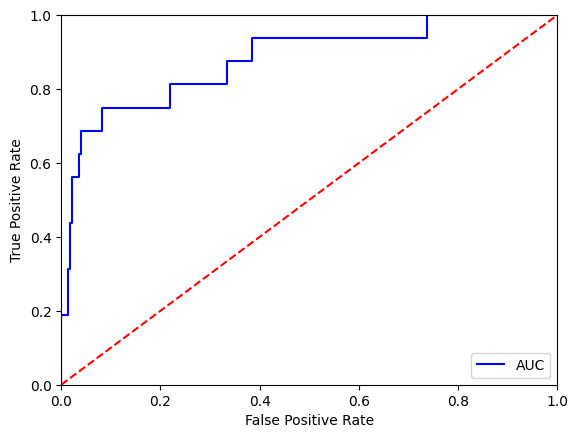

Accuracy for MTDNN on Morgan Fingerprint: 0.7324159021406728
F1 for MTDNN on Morgan Fingerprint: 0.24892703862660948
 True Positive: 0.725
 True Negative: 0.7328990228013029
False Positive: 0.2671009771986971
False Negative: 0.275
Test ROC AUC (SR-HSE): 0.7934039087947883


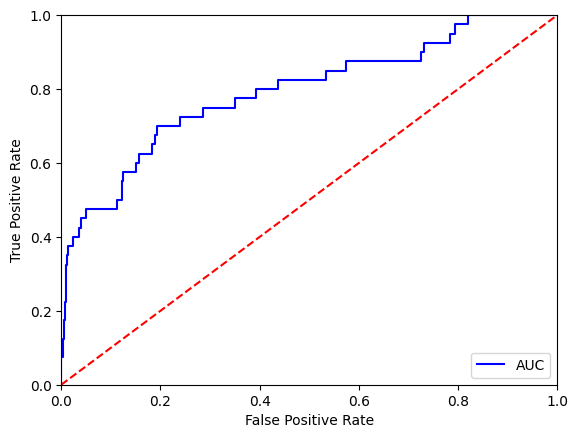

Accuracy for MTDNN on Morgan Fingerprint: 0.9414348462664714
F1 for MTDNN on Morgan Fingerprint: 0.47368421052631576
 True Positive: 0.782608695652174
 True Negative: 0.946969696969697
False Positive: 0.05303030303030303
False Negative: 0.21739130434782608
Test ROC AUC (NR-AR-LBD): 0.922068511198946


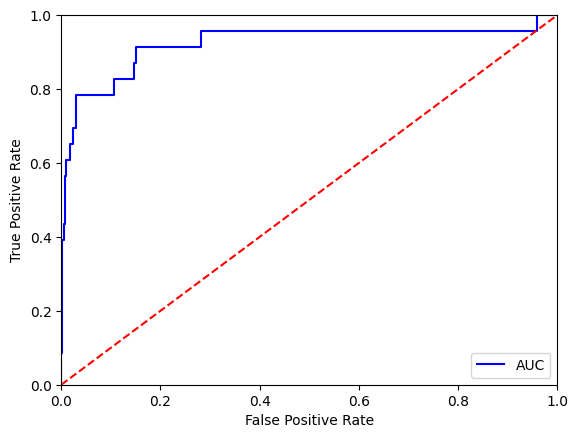

Accuracy for MTDNN on Morgan Fingerprint: 0.3943217665615142
F1 for MTDNN on Morgan Fingerprint: 0.2699619771863118
 True Positive: 0.8255813953488372
 True Negative: 0.3266423357664234
False Positive: 0.6733576642335767
False Negative: 0.1744186046511628
Test ROC AUC (NR-ER): 0.6922530130707859


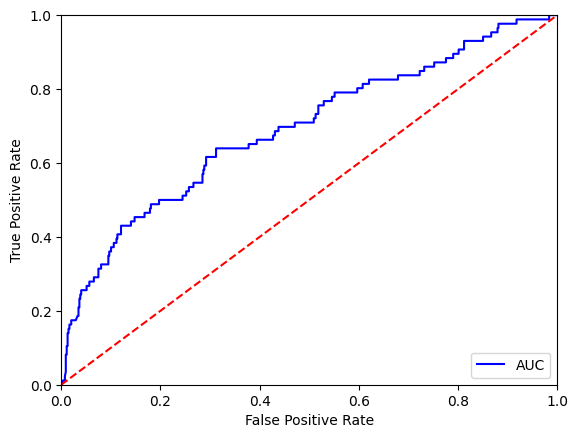

Accuracy for MTDNN on Morgan Fingerprint: 0.5475792988313857
F1 for MTDNN on Morgan Fingerprint: 0.38548752834467115
 True Positive: 0.9444444444444444
 True Negative: 0.4774066797642436
False Positive: 0.5225933202357563
False Negative: 0.05555555555555555
Test ROC AUC (SR-ARE): 0.7930364549225061


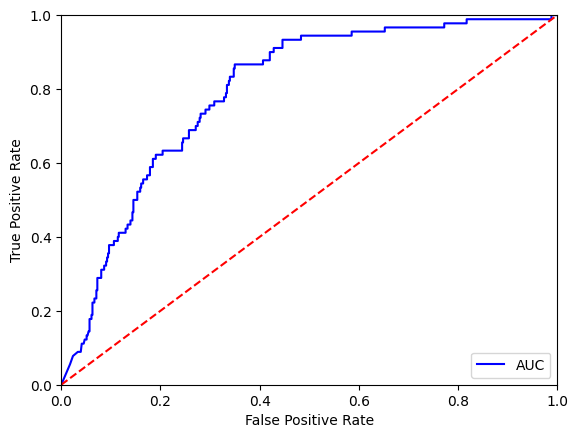

Accuracy for MTDNN on Morgan Fingerprint: 0.6307420494699647
F1 for MTDNN on Morgan Fingerprint: 0.4426666666666667
 True Positive: 0.9222222222222223
 True Negative: 0.5756302521008403
False Positive: 0.42436974789915966
False Negative: 0.07777777777777778
Test ROC AUC (SR-MMP): 0.883718487394958


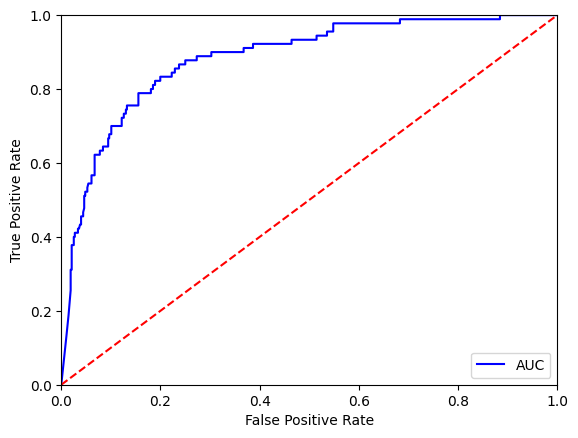

Accuracy for MTDNN on Morgan Fingerprint: 0.6671709531013615
F1 for MTDNN on Morgan Fingerprint: 0.36046511627906974
 True Positive: 0.8732394366197183
 True Negative: 0.6423728813559322
False Positive: 0.3576271186440678
False Negative: 0.1267605633802817
Test ROC AUC (NR-AhR): 0.8078061589878253


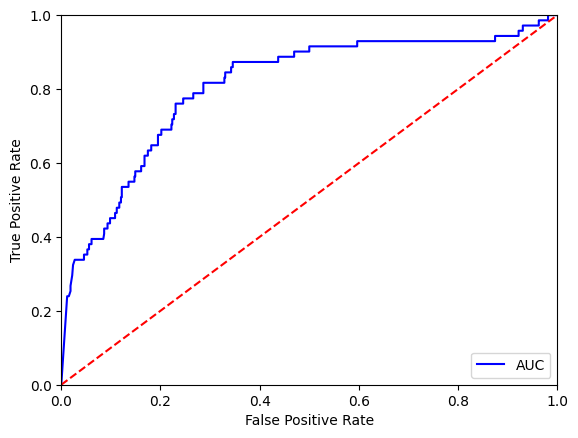

Accuracy for MTDNN on Morgan Fingerprint: 0.796875
F1 for MTDNN on Morgan Fingerprint: 0.2814070351758794
 True Positive: 0.7777777777777778
 True Negative: 0.7979041916167665
False Positive: 0.20209580838323354
False Negative: 0.2222222222222222
Test ROC AUC (NR-ER-LBD): 0.8526072854291418


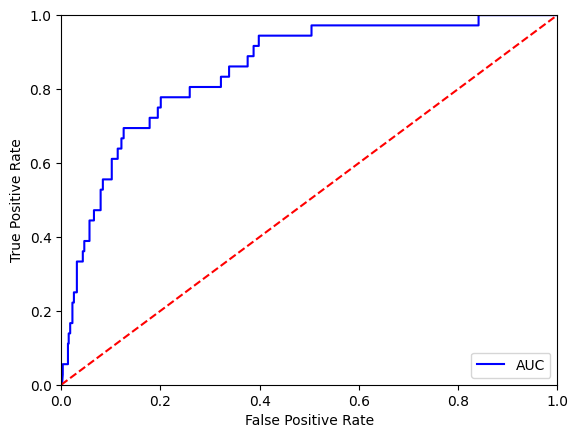

Accuracy for MTDNN on Morgan Fingerprint: 0.8924581005586593
F1 for MTDNN on Morgan Fingerprint: 0.3418803418803419
 True Positive: 0.6896551724137931
 True Negative: 0.901018922852984
False Positive: 0.09898107714701601
False Negative: 0.3103448275862069
Test ROC AUC (SR-ATAD5): 0.8711037494353261


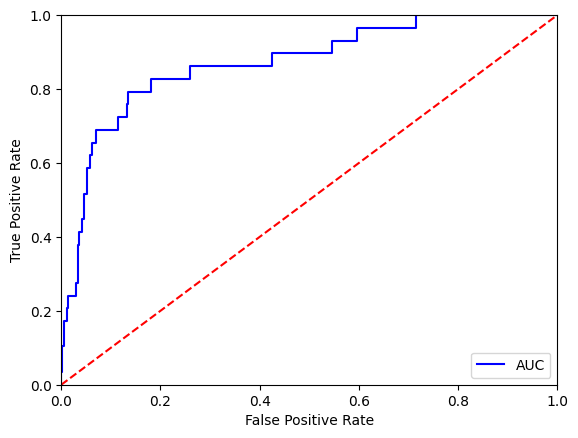

Accuracy for MTDNN on Morgan Fingerprint: 0.6897058823529412
F1 for MTDNN on Morgan Fingerprint: 0.254416961130742
 True Positive: 0.9
 True Negative: 0.6765625
False Positive: 0.3234375
False Negative: 0.1
Test ROC AUC (SR-p53): 0.8321484375


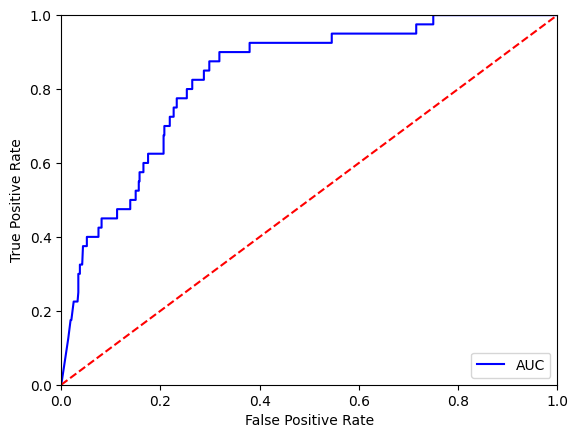

In [43]:
results = {}
# Collects performance metrics for all tasks on test set
for i in range(len(all_tasks)):
    
    valid_datapoints = y_test[:,i] >= 0
    y_test_task = y_test[valid_datapoints,i] 
    y_test_pred_task = y_test_pred[i].detach().numpy()[valid_datapoints,0]
    
    acc = accuracy_score(y_test_task, np.round(y_test_pred_task))
    print('Accuracy for MTDNN on Morgan Fingerprint:', acc)
    
    bacc = sk.metrics.balanced_accuracy_score(y_test_task, np.round(y_test_pred_task))

    f1 = f1_score(y_test_task, np.round(y_test_pred_task), pos_label=1)
    print('F1 for MTDNN on Morgan Fingerprint:', f1)

    cfm = sk.metrics.confusion_matrix(y_test_task, np.round(y_test_pred_task))
    cfm = cfm.astype('float') / cfm.sum(axis=1)[:, np.newaxis]

    tn, fp, fn, tp = cfm.ravel()
    pr = tp / (tp + fp)
    rc = tp / (tp + fn)
    print(' True Positive:', tp)
    print(' True Negative:', tn)
    print('False Positive:', fp)
    print('False Negative:', fn)
    
    
    auc = roc_auc_score(y_test_task, y_test_pred_task)
    print('Test ROC AUC ({}):'.format(all_tasks[i]), auc)
    
    results[all_tasks[i]] = [auc, acc, bacc, tn, tp, pr, rc, f1]

    fpr, tpr, threshold = sk.metrics.roc_curve(y_test_task, y_test_pred_task)
    plt.plot(fpr, tpr, 'b', label = 'AUC')
    plt.legend(loc = 'lower right')
    plt.plot([0, 1], [0, 1],'r--')
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()

In [44]:
print('Task'.ljust(10), '\t', '  AUC ', ' ACC ', ' BACC ', ' TN  ', ' TP  ', ' PR  ', ' RC  ', ' F1  ')
for task, auc in results.items():
    print(task.ljust(10), '\t', np.round(auc,3))

Task       	   AUC   ACC   BACC   TN    TP    PR    RC    F1  
NR-AR      	 [0.84  0.803 0.771 0.806 0.735 0.791 0.735 0.256]
NR-Aromatase 	 [0.809 0.791 0.775 0.793 0.757 0.786 0.757 0.315]
NR-PPAR-gamma 	 [0.879 0.921 0.807 0.927 0.688 0.904 0.688 0.301]
SR-HSE     	 [0.793 0.732 0.729 0.733 0.725 0.731 0.725 0.249]
NR-AR-LBD  	 [0.922 0.941 0.865 0.947 0.783 0.937 0.783 0.474]
NR-ER      	 [0.692 0.394 0.576 0.327 0.826 0.551 0.826 0.27 ]
SR-ARE     	 [0.793 0.548 0.711 0.477 0.944 0.644 0.944 0.385]
SR-MMP     	 [0.884 0.631 0.749 0.576 0.922 0.685 0.922 0.443]
NR-AhR     	 [0.808 0.667 0.758 0.642 0.873 0.709 0.873 0.36 ]
NR-ER-LBD  	 [0.853 0.797 0.788 0.798 0.778 0.794 0.778 0.281]
SR-ATAD5   	 [0.871 0.892 0.795 0.901 0.69  0.874 0.69  0.342]
SR-p53     	 [0.832 0.69  0.788 0.677 0.9   0.736 0.9   0.254]


##### See Valid set performance

In [45]:
# print test loss
for x_valid_torch, y_valid_torch in valid_generator:
    y_valid_pred = model.eval().to(device).cpu()(x_valid_torch)
    
    # Compute loss over all tasks
    loss = 0
    for i in range(len(all_tasks)):
        y_test_task = y_valid_torch[:,i]
        y_pred_task  = y_valid_pred[i][:,0]

        # compute loss for labels that are not NA
        indice_valid = y_test_task >= 0
        loss_task = criterion(y_pred_task[indice_valid], y_test_task[indice_valid]) / N_test[i]

        loss += loss_task
    
print(loss.item())

0.0416223481297493


Accuracy for deepnn on Morgan Fingerprint: 0.7926509186351706
F1 for deepnn on Morgan Fingerprint: 0.17708333333333334
Confusion Matrix for deepnn on Morgan Fingerprint:
 [[0.79972752 0.20027248]
 [0.39285714 0.60714286]]
 True Positive: 0.6071428571428571
 True Negative: 0.7997275204359673
False Positive: 0.20027247956403268
False Negative: 0.39285714285714285
Test ROC AUC (NR-AR): 0.7595367847411444


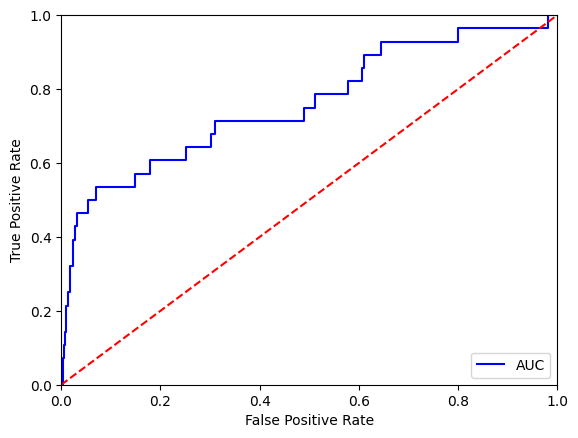

Accuracy for deepnn on Morgan Fingerprint: 0.7939698492462312
F1 for deepnn on Morgan Fingerprint: 0.23602484472049687
Confusion Matrix for deepnn on Morgan Fingerprint:
 [[0.78993056 0.21006944]
 [0.0952381  0.9047619 ]]
 True Positive: 0.9047619047619048
 True Negative: 0.7899305555555556
False Positive: 0.21006944444444445
False Negative: 0.09523809523809523
Test ROC AUC (NR-Aromatase): 0.8818617724867726


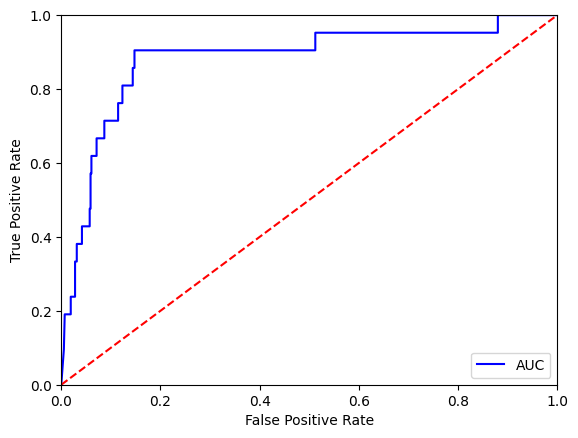

Accuracy for deepnn on Morgan Fingerprint: 0.9340329835082459
F1 for deepnn on Morgan Fingerprint: 0.3529411764705882
Confusion Matrix for deepnn on Morgan Fingerprint:
 [[0.94875776 0.05124224]
 [0.47826087 0.52173913]]
 True Positive: 0.5217391304347826
 True Negative: 0.9487577639751553
False Positive: 0.05124223602484472
False Negative: 0.4782608695652174
Test ROC AUC (NR-PPAR-gamma): 0.846948420199838


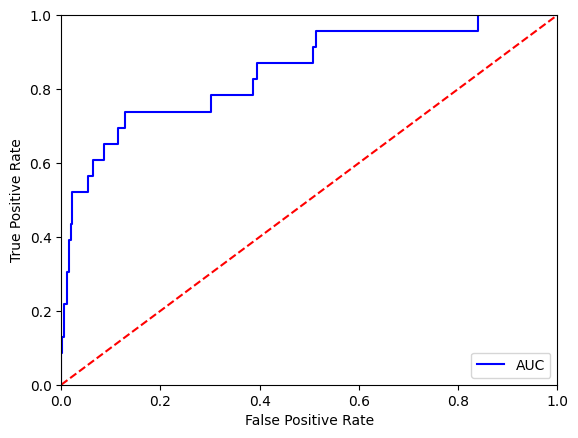

Accuracy for deepnn on Morgan Fingerprint: 0.7616892911010558
F1 for deepnn on Morgan Fingerprint: 0.2818181818181818
Confusion Matrix for deepnn on Morgan Fingerprint:
 [[0.75961538 0.24038462]
 [0.20512821 0.79487179]]
 True Positive: 0.7948717948717948
 True Negative: 0.7596153846153846
False Positive: 0.2403846153846154
False Negative: 0.20512820512820512
Test ROC AUC (SR-HSE): 0.8109590729783038


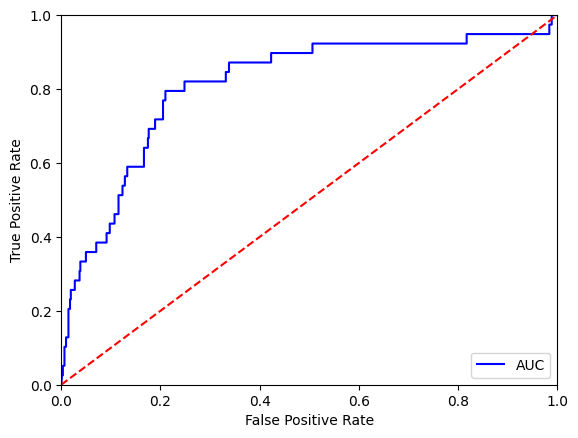

Accuracy for deepnn on Morgan Fingerprint: 0.9456366237482118
F1 for deepnn on Morgan Fingerprint: 0.3666666666666667
Confusion Matrix for deepnn on Morgan Fingerprint:
 [[0.96153846 0.03846154]
 [0.52173913 0.47826087]]
 True Positive: 0.4782608695652174
 True Negative: 0.9615384615384616
False Positive: 0.038461538461538464
False Negative: 0.5217391304347826
Test ROC AUC (NR-AR-LBD): 0.8264085412914843


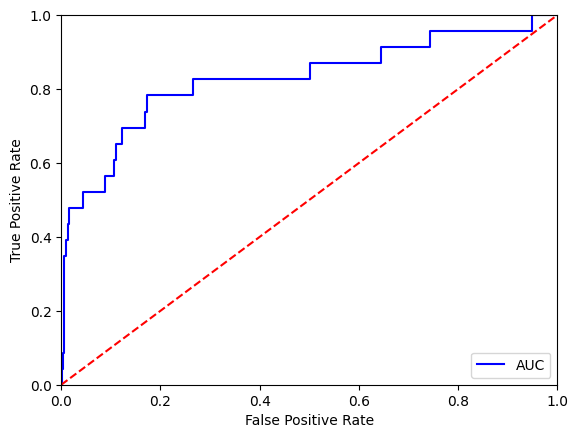

Accuracy for deepnn on Morgan Fingerprint: 0.41756548536209553
F1 for deepnn on Morgan Fingerprint: 0.264591439688716
Confusion Matrix for deepnn on Morgan Fingerprint:
 [[0.35551664 0.64448336]
 [0.12820513 0.87179487]]
 True Positive: 0.8717948717948718
 True Negative: 0.3555166374781086
False Positive: 0.6444833625218914
False Negative: 0.1282051282051282
Test ROC AUC (NR-ER): 0.7303314023979524


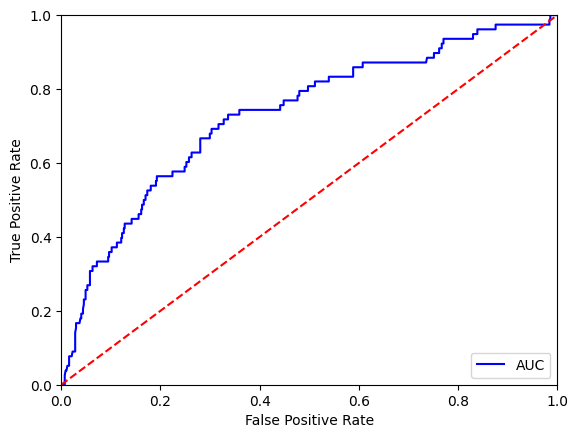

Accuracy for deepnn on Morgan Fingerprint: 0.5759599332220368
F1 for deepnn on Morgan Fingerprint: 0.4147465437788018
Confusion Matrix for deepnn on Morgan Fingerprint:
 [[0.50898204 0.49101796]
 [0.08163265 0.91836735]]
 True Positive: 0.9183673469387755
 True Negative: 0.5089820359281437
False Positive: 0.49101796407185627
False Negative: 0.08163265306122448
Test ROC AUC (SR-ARE): 0.8092182980976823


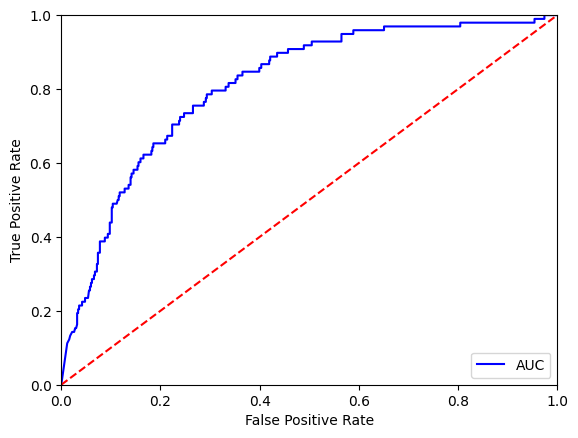

Accuracy for deepnn on Morgan Fingerprint: 0.6715686274509803
F1 for deepnn on Morgan Fingerprint: 0.49370277078085645
Confusion Matrix for deepnn on Morgan Fingerprint:
 [[0.61614173 0.38385827]
 [0.05769231 0.94230769]]
 True Positive: 0.9423076923076923
 True Negative: 0.6161417322834646
False Positive: 0.3838582677165354
False Negative: 0.057692307692307696
Test ROC AUC (SR-MMP): 0.8823061780738947


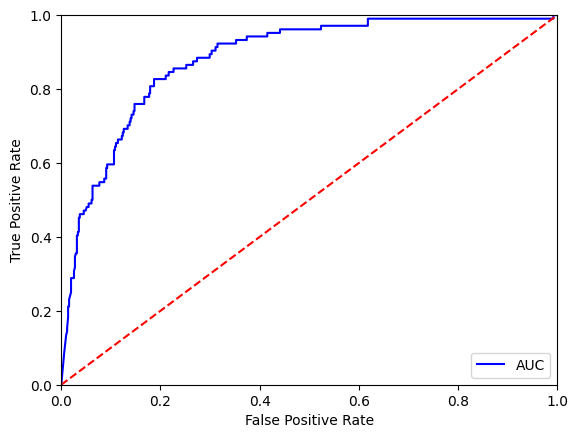

Accuracy for deepnn on Morgan Fingerprint: 0.7194767441860465
F1 for deepnn on Morgan Fingerprint: 0.4469914040114613
Confusion Matrix for deepnn on Morgan Fingerprint:
 [[0.69154229 0.30845771]
 [0.08235294 0.91764706]]
 True Positive: 0.9176470588235294
 True Negative: 0.6915422885572139
False Positive: 0.30845771144278605
False Negative: 0.08235294117647059
Test ROC AUC (NR-AhR): 0.872929470295581


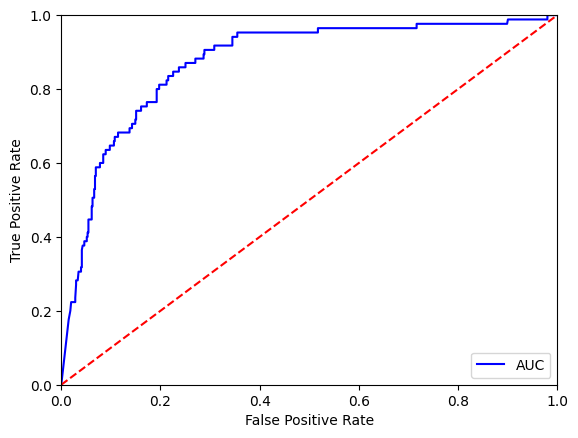

Accuracy for deepnn on Morgan Fingerprint: 0.7988980716253443
F1 for deepnn on Morgan Fingerprint: 0.2065217391304348
Confusion Matrix for deepnn on Morgan Fingerprint:
 [[0.80719424 0.19280576]
 [0.38709677 0.61290323]]
 True Positive: 0.6129032258064516
 True Negative: 0.8071942446043165
False Positive: 0.19280575539568345
False Negative: 0.3870967741935484
Test ROC AUC (NR-ER-LBD): 0.7711533998607566


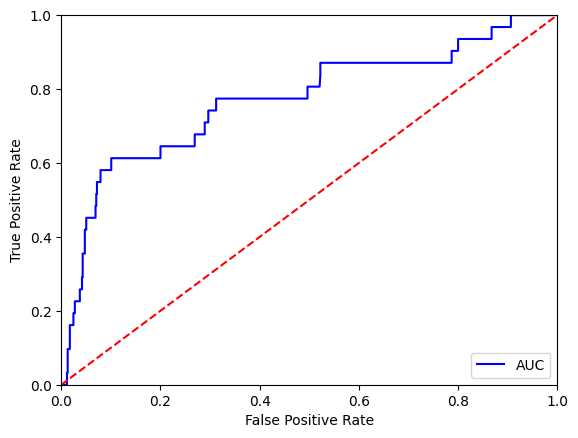

Accuracy for deepnn on Morgan Fingerprint: 0.8857142857142857
F1 for deepnn on Morgan Fingerprint: 0.3225806451612903
Confusion Matrix for deepnn on Morgan Fingerprint:
 [[0.89503546 0.10496454]
 [0.33333333 0.66666667]]
 True Positive: 0.6666666666666666
 True Negative: 0.8950354609929078
False Positive: 0.1049645390070922
False Negative: 0.3333333333333333
Test ROC AUC (SR-ATAD5): 0.8887234042553191


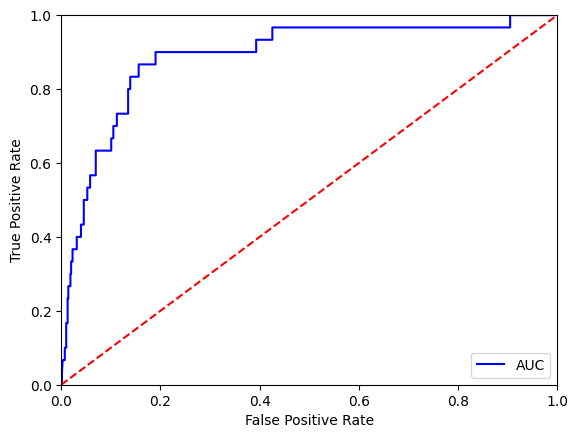

Accuracy for deepnn on Morgan Fingerprint: 0.6951566951566952
F1 for deepnn on Morgan Fingerprint: 0.2517482517482518
Confusion Matrix for deepnn on Morgan Fingerprint:
 [[0.68484848 0.31515152]
 [0.14285714 0.85714286]]
 True Positive: 0.8571428571428571
 True Negative: 0.6848484848484848
False Positive: 0.3151515151515151
False Negative: 0.14285714285714285
Test ROC AUC (SR-p53): 0.8475288600288601


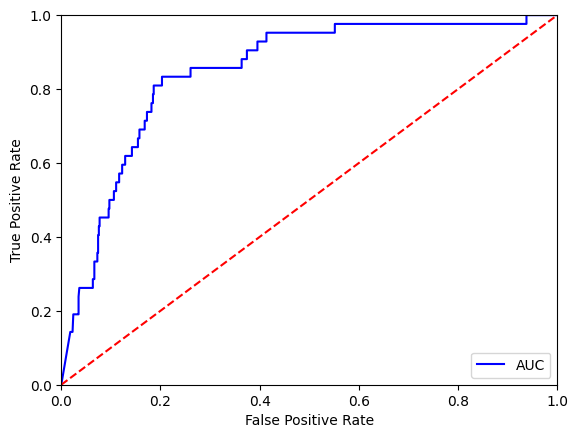

In [46]:
results_valid = {}
# Collects performance metrics for all tasks on Valid set
for i in range(len(all_tasks)):
    
    valid_datapoints = y_valid[:,i] >= 0
    y_valid_task = y_valid[valid_datapoints,i] 
    y_valid_pred_task = y_valid_pred[i].detach().numpy()[valid_datapoints,0]
    
    
    acc = accuracy_score(y_valid_task, np.round(y_valid_pred_task))
    print('Accuracy for deepnn on Morgan Fingerprint:', acc)
    
    bacc = sk.metrics.balanced_accuracy_score(y_valid_task, np.round(y_valid_pred_task))

    f1 = f1_score(y_valid_task, np.round(y_valid_pred_task), pos_label=1)
    print('F1 for deepnn on Morgan Fingerprint:', f1)

    cfm = sk.metrics.confusion_matrix(y_valid_task, np.round(y_valid_pred_task))
    cfm = cfm.astype('float') / cfm.sum(axis=1)[:, np.newaxis]

    print('Confusion Matrix for deepnn on Morgan Fingerprint:\n', cfm)

    tn, fp, fn, tp = cfm.ravel()
    pr = tp / (tp + fp)
    rc = tp / (tp + fn)
    print(' True Positive:', tp)
    print(' True Negative:', tn)
    print('False Positive:', fp)
    print('False Negative:', fn)
    
    
    auc = roc_auc_score(y_valid_task, y_valid_pred_task)
    print('Test ROC AUC ({}):'.format(all_tasks[i]), auc)
    
    results_valid[all_tasks[i]] = [auc, acc, bacc, tn, tp, pr, rc, f1]

    fpr, tpr, threshold = sk.metrics.roc_curve(y_valid_task, y_valid_pred_task)
    plt.plot(fpr, tpr, 'b', label = 'AUC')
    plt.legend(loc = 'lower right')
    plt.plot([0, 1], [0, 1],'r--')
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()

In [47]:
print('Task'.ljust(10), '\t', '  AUC ', ' ACC ', ' BACC ', ' TN  ', ' TP  ', ' PR  ', ' RC  ', ' F1  ')
for task, auc in results_valid.items():
    print(task.ljust(10), '\t', np.round(auc,3))

Task       	   AUC   ACC   BACC   TN    TP    PR    RC    F1  
NR-AR      	 [0.76  0.793 0.703 0.8   0.607 0.752 0.607 0.177]
NR-Aromatase 	 [0.882 0.794 0.847 0.79  0.905 0.812 0.905 0.236]
NR-PPAR-gamma 	 [0.847 0.934 0.735 0.949 0.522 0.911 0.522 0.353]
SR-HSE     	 [0.811 0.762 0.777 0.76  0.795 0.768 0.795 0.282]
NR-AR-LBD  	 [0.826 0.946 0.72  0.962 0.478 0.926 0.478 0.367]
NR-ER      	 [0.73  0.418 0.614 0.356 0.872 0.575 0.872 0.265]
SR-ARE     	 [0.809 0.576 0.714 0.509 0.918 0.652 0.918 0.415]
SR-MMP     	 [0.882 0.672 0.779 0.616 0.942 0.711 0.942 0.494]
NR-AhR     	 [0.873 0.719 0.805 0.692 0.918 0.748 0.918 0.447]
NR-ER-LBD  	 [0.771 0.799 0.71  0.807 0.613 0.761 0.613 0.207]
SR-ATAD5   	 [0.889 0.886 0.781 0.895 0.667 0.864 0.667 0.323]
SR-p53     	 [0.848 0.695 0.771 0.685 0.857 0.731 0.857 0.252]
